# Analyse du système électrique français (RTE)
## Auteur : Kadiatou Thiongane

Importation des libreries

In [2]:
import pandas as pd
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
import os
os.makedirs("images", exist_ok=True) #dossier dans lequel mettre les images

In [3]:
df = pd.read_parquet("eco2mix-regional-cons-def.parquet")

# Découverte du dataset

In [4]:
# découverte du dataset
display(df.head())
display(df.tail())

,code_insee_region,libelle_region,nature,date,heure,date_heure,consommation,thermique,nucleaire,eolien,...,tch_nucleaire,tco_eolien,tch_eolien,tco_solaire,tch_solaire,tco_hydraulique,tch_hydraulique,tco_bioenergies,tch_bioenergies,column_30
0,76,Occitanie,Données définitives,2013-01-01,00:00,2013-01-01 00:00:00+01:00,NaN,NaN,NaN,ND,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
1,53,Bretagne,Données définitives,2013-01-01,00:00,2013-01-01 00:00:00+01:00,NaN,NaN,NaN,ND,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
2,27,Bourgogne-Franche-Comté,Données définitives,2013-01-01,00:00,2013-01-01 00:00:00+01:00,NaN,NaN,NaN,ND,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
3,84,Auvergne-Rhône-Alpes,Données définitives,2013-01-01,00:00,2013-01-01 00:00:00+01:00,NaN,NaN,NaN,ND,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None
4,32,Hauts-de-France,Données définitives,2013-01-01,00:00,2013-01-01 00:00:00+01:00,NaN,NaN,NaN,ND,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None


,code_insee_region,libelle_region,nature,date,heure,date_heure,consommation,thermique,nucleaire,eolien,...,tch_nucleaire,tco_eolien,tch_eolien,tco_solaire,tch_solaire,tco_hydraulique,tch_hydraulique,tco_bioenergies,tch_bioenergies,column_30
2524603,84,Auvergne-Rhône-Alpes,Données consolidées,2024-12-31,23:30,2024-12-31 23:30:00+01:00,9488.0,112.0,11457.0,115,...,84.43,1.21,15.71,0.00,0.00,26.36,21.86,1.19,56.22,None
2524604,44,Grand Est,Données consolidées,2024-12-31,23:30,2024-12-31 23:30:00+01:00,5521.0,173.0,10713.0,1042,...,99.01,18.87,21.07,0.00,0.00,12.97,31.09,2.92,64.66,None
2524605,75,Nouvelle-Aquitaine,Données consolidées,2024-12-31,23:30,2024-12-31 23:30:00+01:00,6828.0,100.0,5061.0,303,...,76.33,4.44,14.93,0.00,0.00,6.81,20.74,2.65,50.70,None
2524606,93,Provence-Alpes-Côte d'Azur,Données consolidées,2024-12-31,23:30,2024-12-31 23:30:00+01:00,5908.0,685.0,0.0,0,...,NaN,0.00,0.00,0.02,0.04,9.31,17.04,2.22,40.43,None
2524607,32,Hauts-de-France,Données consolidées,2024-12-31,23:30,2024-12-31 23:30:00+01:00,5818.0,199.0,4558.0,4953,...,83.48,85.13,78.22,0.00,0.00,0.03,50.00,2.11,62.44,None


In [5]:
# nombre de ligne et nombre de colonne
df.shape

(2524608, 32)

In [6]:
df.tail()

,code_insee_region,libelle_region,nature,date,heure,date_heure,consommation,thermique,nucleaire,eolien,...,tch_nucleaire,tco_eolien,tch_eolien,tco_solaire,tch_solaire,tco_hydraulique,tch_hydraulique,tco_bioenergies,tch_bioenergies,column_30
2524603,84,Auvergne-Rhône-Alpes,Données consolidées,2024-12-31,23:30,2024-12-31 23:30:00+01:00,9488.0,112.0,11457.0,115,...,84.43,1.21,15.71,0.00,0.00,26.36,21.86,1.19,56.22,None
2524604,44,Grand Est,Données consolidées,2024-12-31,23:30,2024-12-31 23:30:00+01:00,5521.0,173.0,10713.0,1042,...,99.01,18.87,21.07,0.00,0.00,12.97,31.09,2.92,64.66,None
2524605,75,Nouvelle-Aquitaine,Données consolidées,2024-12-31,23:30,2024-12-31 23:30:00+01:00,6828.0,100.0,5061.0,303,...,76.33,4.44,14.93,0.00,0.00,6.81,20.74,2.65,50.70,None
2524606,93,Provence-Alpes-Côte d'Azur,Données consolidées,2024-12-31,23:30,2024-12-31 23:30:00+01:00,5908.0,685.0,0.0,0,...,NaN,0.00,0.00,0.02,0.04,9.31,17.04,2.22,40.43,None
2524607,32,Hauts-de-France,Données consolidées,2024-12-31,23:30,2024-12-31 23:30:00+01:00,5818.0,199.0,4558.0,4953,...,83.48,85.13,78.22,0.00,0.00,0.03,50.00,2.11,62.44,None


In [7]:
# découverte du dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2524608 entries, 0 to 2524607
Data columns (total 32 columns):
 #   Column               Dtype                        
---  ------               -----                        
 0   code_insee_region    object                       
 1   libelle_region       object                       
 2   nature               object                       
 3   date                 object                       
 4   heure                object                       
 5   date_heure           datetime64[ms, Europe/Berlin]
 6   consommation         float64                      
 7   thermique            float64                      
 8   nucleaire            float64                      
 9   eolien               object                       
 10  solaire              float64                      
 11  hydraulique          float64                      
 12  pompage              float64                      
 13  bioenergies          float64              

In [8]:
# Nom des colonnes
df.columns

Index(['code_insee_region', 'libelle_region', 'nature', 'date', 'heure',
       'date_heure', 'consommation', 'thermique', 'nucleaire', 'eolien',
       'solaire', 'hydraulique', 'pompage', 'bioenergies', 'ech_physiques',
       'stockage_batterie', 'destockage_batterie', 'eolien_terrestre',
       'eolien_offshore', 'tco_thermique', 'tch_thermique', 'tco_nucleaire',
       'tch_nucleaire', 'tco_eolien', 'tch_eolien', 'tco_solaire',
       'tch_solaire', 'tco_hydraulique', 'tch_hydraulique', 'tco_bioenergies',
       'tch_bioenergies', 'column_30'],
      dtype='object')

# Exploration des données

In [9]:
#on recherche s'il y des valeurs manquantes (NaN)
print(df.isna().sum())

code_insee_region            0
libelle_region               0
nature                       0
date                         0
heure                        0
date_heure                   0
consommation                12
thermique                   12
nucleaire               701287
eolien                       0
solaire                     12
hydraulique                 12
pompage                 736327
bioenergies                 12
ech_physiques               12
stockage_batterie      1683084
destockage_batterie    1683084
eolien_terrestre       1683084
eolien_offshore        1683084
tco_thermique          1472256
tch_thermique          1472256
tco_nucleaire          1560096
tch_nucleaire          1910736
tco_eolien             1472256
tch_eolien             1472256
tco_solaire            1472256
tch_solaire            1472256
tco_hydraulique        1472256
tch_hydraulique        1472256
tco_bioenergies        1472256
tch_bioenergies        1472256
column_30              2524608
dtype: i

In [10]:
#on a remarqué qu'il y avait de nombreuses valeurs manquantes, on calcule les pourcentages de NA par colonne
print((df.isna().mean().round(2)))

code_insee_region      0.00
libelle_region         0.00
nature                 0.00
date                   0.00
heure                  0.00
date_heure             0.00
consommation           0.00
thermique              0.00
nucleaire              0.28
eolien                 0.00
solaire                0.00
hydraulique            0.00
pompage                0.29
bioenergies            0.00
ech_physiques          0.00
stockage_batterie      0.67
destockage_batterie    0.67
eolien_terrestre       0.67
eolien_offshore        0.67
tco_thermique          0.58
tch_thermique          0.58
tco_nucleaire          0.62
tch_nucleaire          0.76
tco_eolien             0.58
tch_eolien             0.58
tco_solaire            0.58
tch_solaire            0.58
tco_hydraulique        0.58
tch_hydraulique        0.58
tco_bioenergies        0.58
tch_bioenergies        0.58
column_30              1.00
dtype: float64


In [11]:
#statistique descriptive
df.describe()

,consommation,thermique,nucleaire,solaire,hydraulique,pompage,bioenergies,ech_physiques,stockage_batterie,destockage_batterie,...,tco_nucleaire,tch_nucleaire,tco_eolien,tch_eolien,tco_solaire,tch_solaire,tco_hydraulique,tch_hydraulique,tco_bioenergies,tch_bioenergies
count,2.524596e+06,2.524596e+06,1.823321e+06,2.524596e+06,2.524596e+06,1.788281e+06,2.524596e+06,2.524596e+06,841524.0,841524.0,...,964512.000000,613872.000000,1.052352e+06,1.052352e+06,1.052352e+06,1.052352e+06,1.052352e+06,1.052352e+06,1.052352e+06,1.052352e+06
mean,4.415041e+03,3.568745e+02,4.855516e+03,1.179882e+02,5.953436e+02,-9.245771e+01,8.728602e+01,-4.798851e+02,0.0,0.0,...,93.644998,60.653776,1.065496e+01,2.450573e+01,4.381139e+00,1.420019e+01,1.126681e+01,2.898343e+01,2.470351e+00,5.638177e+01
std,2.128622e+03,5.202614e+02,3.617621e+03,2.944407e+02,1.019919e+03,2.802208e+02,4.515602e+01,4.259082e+03,0.0,0.0,...,117.267193,19.998429,1.414124e+01,2.242657e+01,9.321322e+00,2.142981e+01,1.634554e+01,2.250655e+01,9.294713e-01,1.249221e+01
min,6.160000e+02,-8.300000e+01,-1.440000e+02,-2.300000e+01,-6.000000e+00,-2.580000e+03,4.000000e+00,-1.278700e+04,0.0,0.0,...,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,5.200000e-01,7.280000e+00
25%,2.732000e+03,2.300000e+01,1.655000e+03,0.000000e+00,5.000000e+00,-6.000000e+00,5.100000e+01,-4.045000e+03,0.0,0.0,...,0.000000,47.450000,1.110000e+00,6.280000e+00,0.000000e+00,0.000000e+00,1.300000e-01,1.208000e+01,1.800000e+00,4.892000e+01
50%,4.057000e+03,1.460000e+02,4.591000e+03,1.000000e+00,5.700000e+01,0.000000e+00,8.100000e+01,5.510000e+02,0.0,0.0,...,58.890000,60.600000,4.990000e+00,1.753000e+01,4.000000e-02,1.900000e-01,2.230000e+00,2.701000e+01,2.280000e+00,5.827000e+01
75%,5.626000e+03,4.420000e+02,7.723000e+03,8.300000e+01,8.730000e+02,0.000000e+00,1.190000e+02,2.168000e+03,0.0,0.0,...,134.810000,74.390000,1.484000e+01,3.711000e+01,4.060000e+00,2.378000e+01,1.793000e+01,4.493000e+01,2.960000e+00,6.575000e+01
max,1.533800e+04,4.293000e+03,1.363200e+04,4.002000e+03,8.468000e+03,0.000000e+00,2.300000e+03,1.395900e+04,0.0,0.0,...,833.270000,102.010000,1.359200e+02,1.255600e+02,1.273200e+02,1.135400e+02,1.655700e+02,2.575000e+03,2.131000e+01,7.187500e+02


## Valeurs manquantes

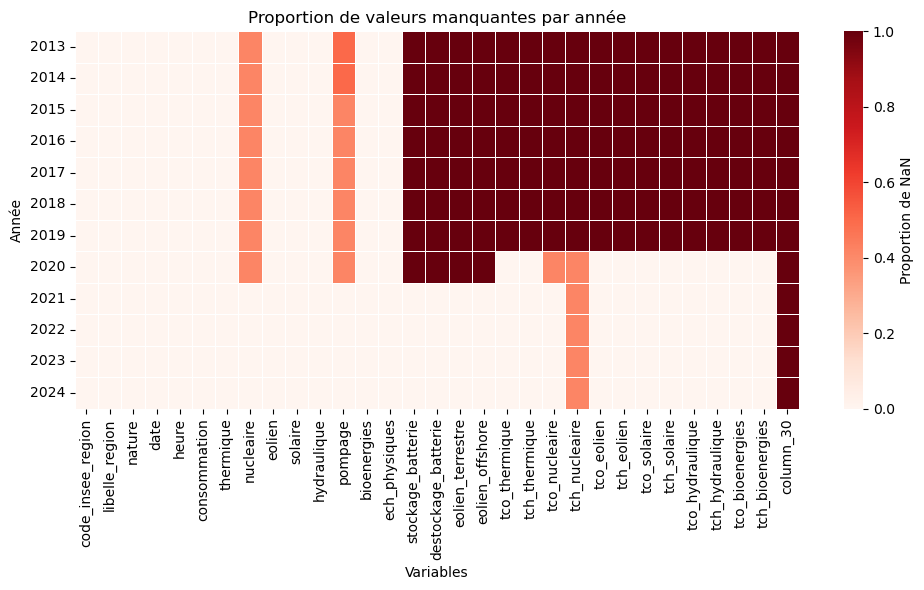

In [12]:
# Graphique Heatmap valeurs manquantes

plt.figure(figsize=(10,6))

yearly_nan = (df.set_index("date_heure").isna().resample("YE").mean())
yearly_nan.index = yearly_nan.index.year

sns.heatmap(yearly_nan,cmap="Reds",cbar_kws={'label': 'Proportion de NaN'},linewidths=0.5)

plt.title("Proportion de valeurs manquantes par année")
plt.xlabel("Variables")
plt.ylabel("Année")

plt.yticks(rotation=0)  
plt.xticks(rotation=90)  

plt.tight_layout()
plt.show()

# Interprétation
L’analyse temporelle des valeurs manquantes met en évidence une incomplétude importante des données avant 2021, suivie d’une amélioration significative sur la période récente. Les variables fondamentales de production et de consommation apparaissent globalement tandis que les indicateurs dérivés (TCH/TCO) demeurent largement indisponibles.


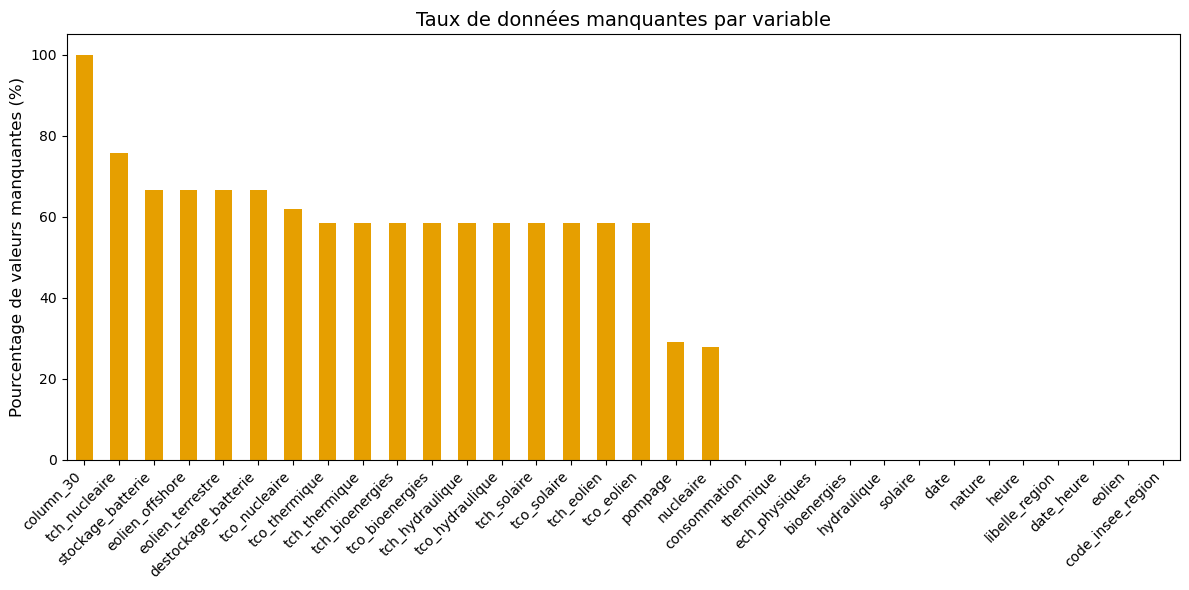

In [13]:

# Calcul
taux_NA_variables = df.isna().mean() * 100
taux_NA_variables = taux_NA_variables.sort_values(ascending=False)

# Figure
plt.figure(figsize=(12,6))

taux_NA_variables.plot(
    kind='bar',
    color='#E69F00'  # orange sobre
)

plt.ylabel("Pourcentage de valeurs manquantes (%)", fontsize=12)
plt.title("Taux de données manquantes par variable", fontsize=14)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Sauvegarde pour Overleaf
plt.savefig("images/taux_NA_variables.pdf", bbox_inches="tight")

plt.show()


# Interprétation
Le jeu de données présente une forte proportion de valeurs manquantes sur certaines variables dérivées (notamment les indicateurs de taux de charge et de couverture). Toutefois, les variables fondamentales nécessaires à l’analyse des déséquilibres production–consommation demeurent complètes, garantissant la faisabilité des analyses principales.

## Valeur abérantes

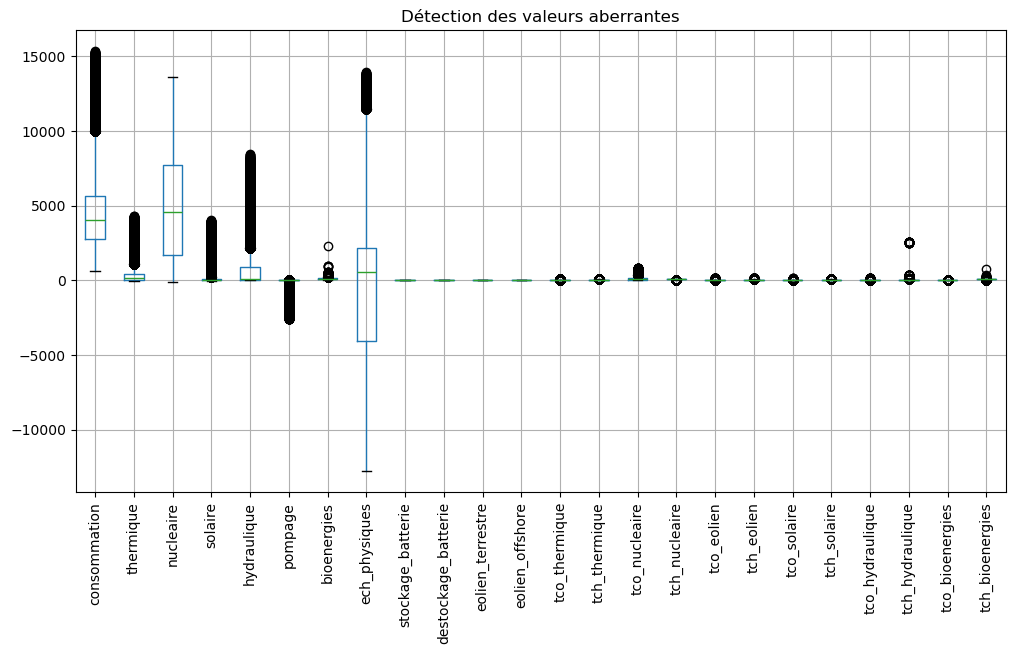

In [14]:
# Nous travaillons sur des puissances en MW. Des valeurs négatives ou énormes peuvent signaler un problème.
# Consommation négative → impossible → erreur 
#Production solaire nocturne → incohérence
#Pics anormalement extrêmes → problème de capteur

variables_numeriques = df.select_dtypes(include='number')
plt.figure(figsize=(12,6))
variables_numeriques.boxplot(rot=90)
plt.title("Détection des valeurs aberrantes")
plt.show()


Problème :
Les échelles sont tellement différentes que :

Les petites filières sont écrasées visuellement

On ne distingue pas les vraies anomalies

L’analyse devient illisible. On sépare en 2 groupes

Les boxplots ont été réalisés par sous-groupes de variables afin de conserver une cohérence d’échelle et d’améliorer la lisibilité. La séparation entre productions pilotables et filières renouvelables/échanges permet une analyse plus fine de la dispersion et des valeurs extrêmes propres à chaque catégorie.

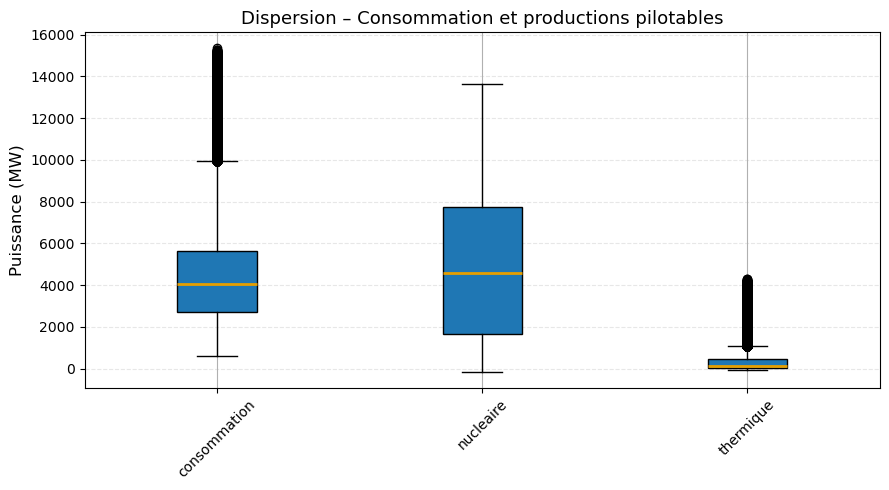

In [15]:
groupe1 = [
    "consommation",
    "nucleaire",
    "thermique"
]

plt.figure(figsize=(9,5))

box = df[groupe1].boxplot(
    patch_artist=True,
    boxprops=dict(facecolor='#1f77b4', color='black'),
    medianprops=dict(color='#E69F00', linewidth=2),
    whiskerprops=dict(color='black'),
    capprops=dict(color='black')
)

plt.title("Dispersion – Consommation et productions pilotables", fontsize=13)
plt.ylabel("Puissance (MW)", fontsize=12)
plt.xticks(rotation=45)

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()


plt.savefig("images/boxplot_pilotables.png", dpi=300, bbox_inches="tight")

plt.show()



# Interprétation
La consommation présente une dispersion importante, reflétant la variabilité saisonnière et journalière.

Le nucléaire montre une distribution relativement stable, avec une variabilité plus contenue.

Le thermique présente une forte asymétrie, traduisant son rôle d’ajustement lors des pics de demande.

# Lecture métier

Les valeurs extrêmes supérieures correspondent probablement aux pics hivernaux.

L’étalement du thermique confirme son rôle de variable d’ajustement.

La dispersion plus maîtrisée du nucléaire reflète son fonctionnement en base.

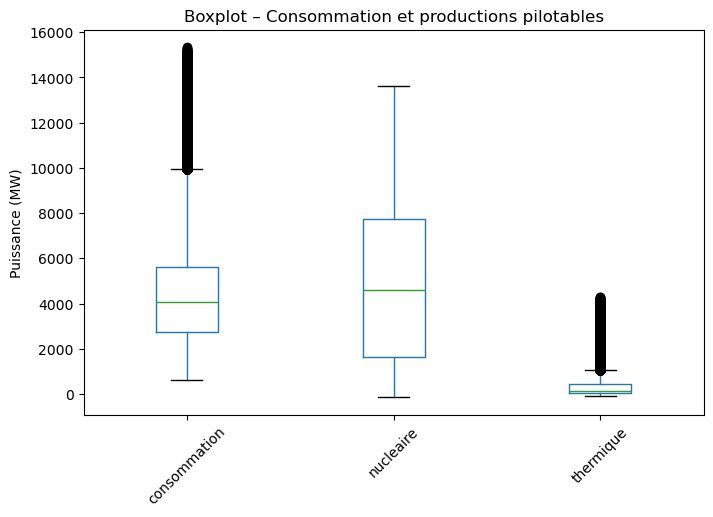

In [16]:


plt.style.use("default")

groupe1 = [
    "consommation",
    "nucleaire",
    "thermique"
]

plt.figure(figsize=(8,5))
df[groupe1].boxplot()

plt.title("Boxplot – Consommation et productions pilotables")
plt.ylabel("Puissance (MW)")
plt.xticks(rotation=45)
plt.grid(False)

plt.show()


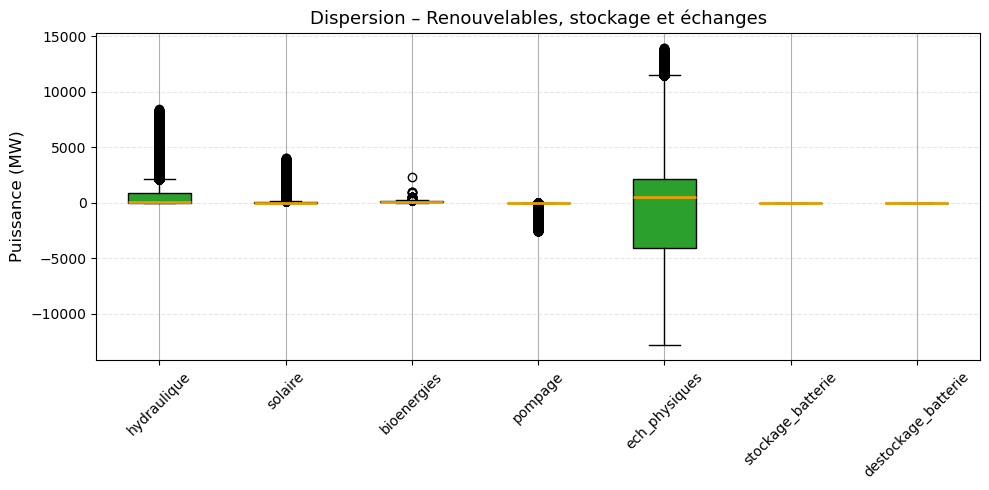

In [17]:

groupe2 = [
    "hydraulique",
    "solaire",
    "bioenergies",
    "pompage",
    "ech_physiques",
    "stockage_batterie",
    "destockage_batterie"
]

plt.figure(figsize=(10,5))

df[groupe2].boxplot(
    patch_artist=True,
    boxprops=dict(facecolor='#2ca02c', color='black'),
    medianprops=dict(color='#E69F00', linewidth=2),
    whiskerprops=dict(color='black'),
    capprops=dict(color='black')
)

plt.title("Dispersion – Renouvelables, stockage et échanges", fontsize=13)
plt.ylabel("Puissance (MW)", fontsize=12)
plt.xticks(rotation=45)

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()

#plt.savefig("images/boxplot_renouvelables.pdf", bbox_inches="tight")
plt.savefig("images/boxplot_renouvelables.png", dpi=300, bbox_inches="tight")


plt.show()


# Interprétation
Les filières renouvelables présentent une forte variabilité, notamment l’hydraulique et le solaire.

Le pompage affiche des valeurs négatives, cohérentes avec son rôle de consommation lors du stockage.

Les échanges physiques présentent une dispersion très importante, traduisant les dynamiques d’import/export entre régions.

# Lecture métier

Les renouvelables sont structurellement plus volatiles.

Les échanges jouent un rôle d’amortisseur des déséquilibres régionaux.

Le stockage reste marginal en volume comparé aux autres filières.

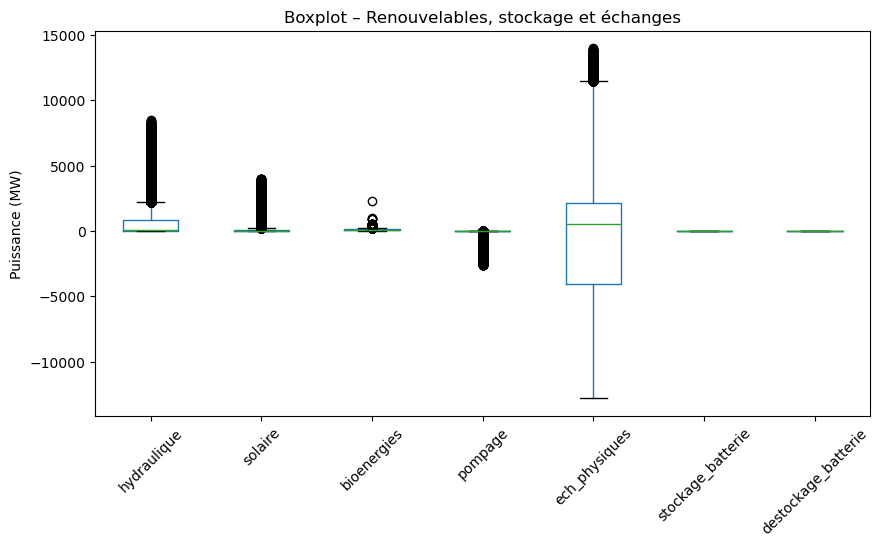

In [18]:
groupe2 = [
    "hydraulique",
    "eolien",
    "solaire",
    "bioenergies",
    "pompage",
    "ech_physiques",
    "stockage_batterie",
    "destockage_batterie"
]

plt.figure(figsize=(10,5))
df[groupe2].boxplot()

plt.title("Boxplot – Renouvelables, stockage et échanges")
plt.ylabel("Puissance (MW)")
plt.xticks(rotation=45)
plt.grid(False)

plt.show()


## Premières tendances 

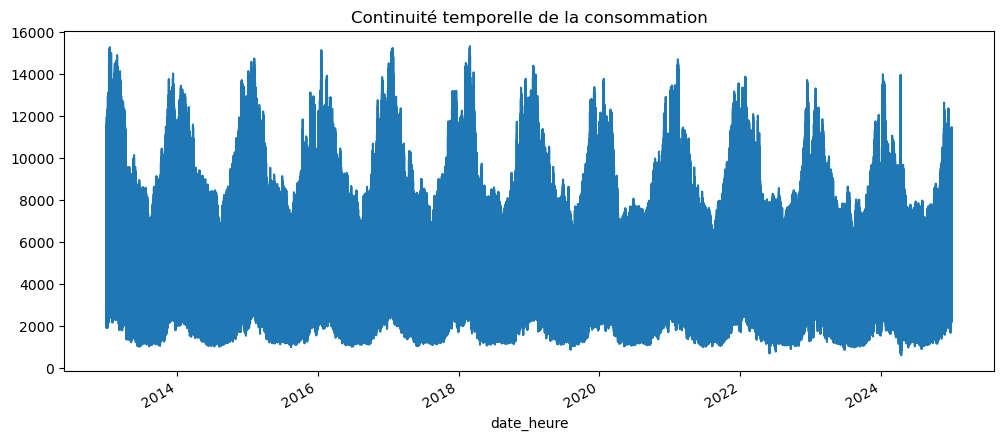

In [19]:
# visualisation de l'évolution de la consommation dans le temps
# Continuité temporelle consommation :
df["date_heure"] = df["date_heure"]
df.set_index("date_heure")["consommation"].plot(figsize=(12,5))
plt.title("Continuité temporelle de la consommation")
plt.show()

# Interprétation
La représentation chronologique de la consommation d’électricité entre 2013 et 2023 met en évidence une continuité satisfaisante des données, sans rupture significative de série.
La saisonnalité annuelle est clairement observable, avec des pics hivernaux marqués et des creux estivaux, conformément aux caractéristiques du système électrique français.


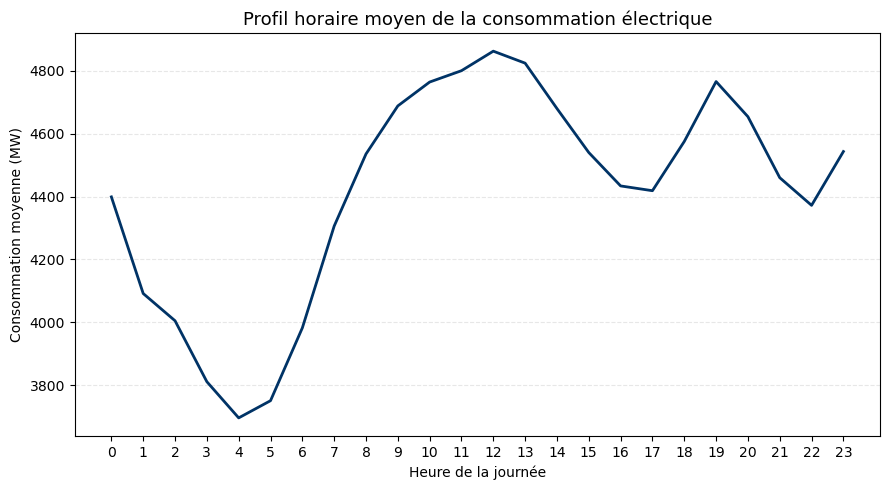

In [20]:
plt.style.use("default")

# Extraction de l'heure
df["heure"] = df["date_heure"].dt.hour

profil_horaire = df.groupby("heure")["consommation"].mean()

plt.figure(figsize=(9,5))

profil_horaire.plot(
    color="#003366",
    linewidth=2
)

plt.title("Profil horaire moyen de la consommation électrique", fontsize=13)
plt.xlabel("Heure de la journée")
plt.ylabel("Consommation moyenne (MW)")

plt.xticks(range(0,24))
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig("images/profil_horaire_consommation.pdf", bbox_inches="tight")

plt.show()

# Interprétation
Le profil horaire moyen met en évidence une forte variabilité intra-journalière, caractérisée par un creux nocturne, une montée rapide le matin et un pic marqué en début de soirée. Cette dynamique traduit la nécessité d’un ajustement permanent entre production et consommation susceptibles de générer des tensions sur le système électrique.

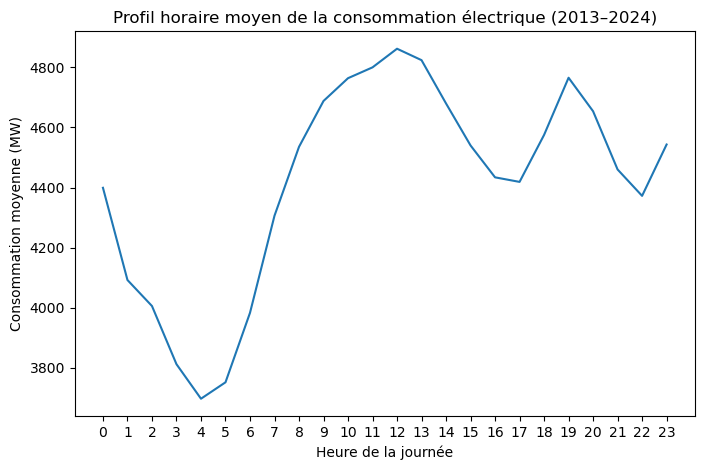

In [21]:
plt.style.use("default")

df["heure"] = df["date_heure"].dt.hour

plt.figure(figsize=(8,5))
df.groupby("heure")["consommation"].mean().plot()

plt.title("Profil horaire moyen de la consommation électrique (2013–2024)")
plt.xlabel("Heure de la journée")
plt.ylabel("Consommation moyenne (MW)")
plt.xticks(range(0,24))

plt.grid(False)   # supprime les lignes horizontales et verticales

plt.show()

## Relation entre les variables

### Relation entre production et consommation

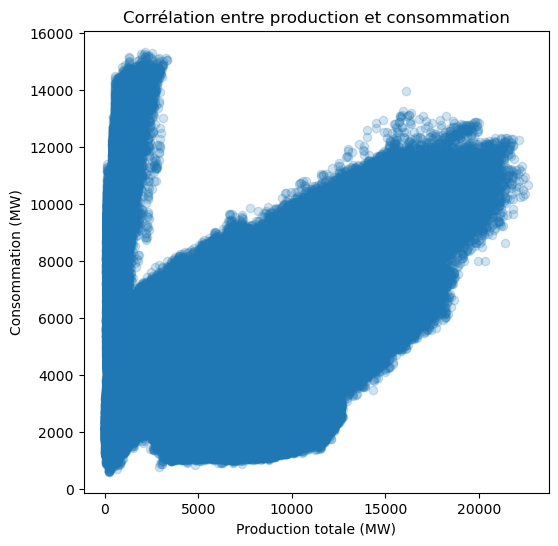

In [22]:
# Colonnes de production à utiliser
colonnes_production = [
    "thermique",
    "nucleaire",
    "eolien",
    "solaire",
    "hydraulique",
    "bioenergies"
]

# Conversion en numérique
for col in colonnes_production + ["consommation"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Création de la variable production totale
df["production_totale"] = df[colonnes_production].sum(axis=1)

# Suppression des lignes avec valeurs manquantes
df_plot = df[["production_totale", "consommation"]].dropna()

# Création du graphique
plt.figure(figsize=(6, 6))
plt.scatter(df_plot["production_totale"], df_plot["consommation"], alpha=0.2)

plt.xlabel("Production totale (MW)")
plt.ylabel("Consommation (MW)")
plt.title("Corrélation entre production et consommation")

plt.show()

### Relation entre les variables énergétiques

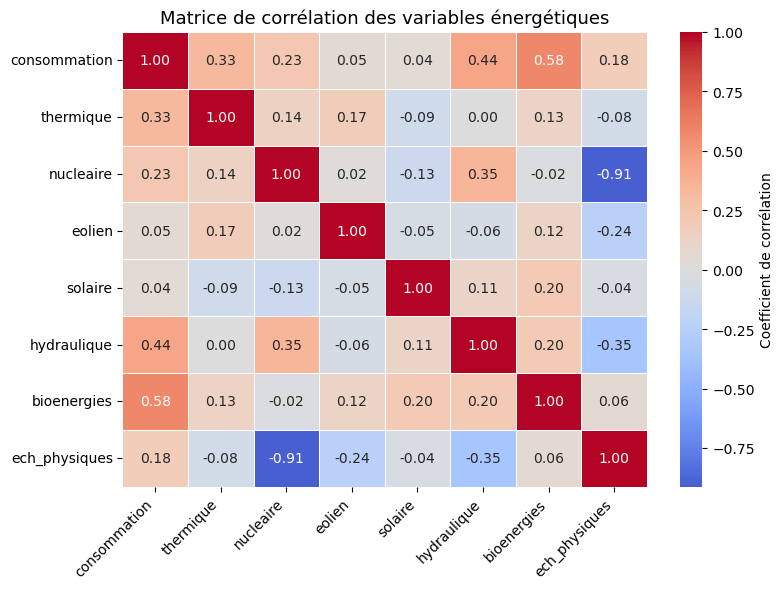

In [23]:
# Remplacer "ND" par NaN
df = df.replace("ND", np.nan)

# Convertir les colonnes énergétiques en numérique
variables_corr = [
    "consommation",
    "thermique",
    "nucleaire",
    "eolien",
    "solaire",
    "hydraulique",
    "bioenergies",
    "ech_physiques"
]

for col in variables_corr:
    df[col] = pd.to_numeric(df[col], errors="coerce")
    # Calcul de la matrice de corrélation
corr_matrix = df[variables_corr].corr()

# Création du graphique
plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,              # Affiche les coefficients
    fmt=".2f",               # 2 décimales
    cmap="coolwarm",         # Palette contrastée
    center=0,                # Blanc autour de 0
    linewidths=0.5,
    cbar_kws={"label": "Coefficient de corrélation"}
)

plt.title("Matrice de corrélation des variables énergétiques", fontsize=13)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()

# Export PDF pour Overleaf
plt.savefig("images/matrice_correlation.pdf", bbox_inches="tight")

plt.show()

# Nétoyage des données

## Suppression des colones non exploitables

In [24]:
colonnes_a_supprimer = [
    "nature",
    "date",
    "heure",
    "stockage_batterie",
    "destockage_batterie",
    "eolien_terrestre",
    "eolien_offshore",
    "tco_thermique",
    "tch_thermique",
    "tco_nucleaire",
    "tch_nucleaire",
    "tch_eolien",
    "tco_eolien",
    "tco_solaire",
    "tch_solaire",
    "tco_hydraulique",
    "tch_hydraulique",
    "tco_bioenergies",
    "tch_bioenergies",
    "column_30"
]
df = df.drop(columns = colonnes_a_supprimer)


In [25]:
df.head(20)

,code_insee_region,libelle_region,date_heure,consommation,thermique,nucleaire,eolien,solaire,hydraulique,pompage,bioenergies,ech_physiques,production_totale
0,76,Occitanie,2013-01-01 00:00:00+01:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
1,53,Bretagne,2013-01-01 00:00:00+01:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
2,27,Bourgogne-Franche-Comté,2013-01-01 00:00:00+01:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
3,84,Auvergne-Rhône-Alpes,2013-01-01 00:00:00+01:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
4,32,Hauts-de-France,2013-01-01 00:00:00+01:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
5,11,Île-de-France,2013-01-01 00:00:00+01:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
6,75,Nouvelle-Aquitaine,2013-01-01 00:00:00+01:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
7,44,Grand Est,2013-01-01 00:00:00+01:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
8,28,Normandie,2013-01-01 00:00:00+01:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
9,52,Pays de la Loire,2013-01-01 00:00:00+01:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0


# Vérification des doublons

In [26]:
nb_doublons_lignes = df.duplicated().sum()
print("Doublons exacts (lignes identiques):", nb_doublons_lignes)

Doublons exacts (lignes identiques): 186


In [27]:
# Vérifier les dates invalides
nb_date_invalide = df["date_heure"].isna().sum()
print("date_heure invalides (NaT):", nb_date_invalide)

date_heure invalides (NaT): 0


In [28]:
# Trier (obligatoire pour cohérence temporelle)
df = df.sort_values(["code_insee_region", "date_heure"]).reset_index(drop=True)

# Doublons sur région et date heure

In [29]:
cle = ["code_insee_region", "date_heure"]
nb_doublons_cle = df.duplicated(subset=cle).sum()
print("Doublons sur la clé (région + date_heure):", nb_doublons_cle)


Doublons sur la clé (région + date_heure): 288


In [30]:
# inspection de quelques cas
doublons = df[df.duplicated(subset=cle, keep=False)].sort_values(cle)
doublons.head(10)


,code_insee_region,libelle_region,date_heure,consommation,thermique,nucleaire,eolien,solaire,hydraulique,pompage,bioenergies,ech_physiques,production_totale
4276,11,Île-de-France,2013-03-31 03:00:00+02:00,9468.0,917.0,NaN,4.0,0.0,4.0,NaN,118.0,8423.0,1043.0
4277,11,Île-de-France,2013-03-31 03:00:00+02:00,9468.0,917.0,NaN,4.0,0.0,4.0,NaN,118.0,8423.0,1043.0
4278,11,Île-de-France,2013-03-31 03:30:00+02:00,9845.0,880.0,NaN,3.0,0.0,4.0,NaN,118.0,8838.0,1005.0
4279,11,Île-de-France,2013-03-31 03:30:00+02:00,9445.0,844.0,NaN,5.0,0.0,4.0,NaN,116.0,8474.0,969.0
21748,11,Île-de-France,2014-03-30 03:00:00+02:00,6490.0,236.0,NaN,4.0,0.0,11.0,NaN,168.0,6071.0,419.0
21749,11,Île-de-France,2014-03-30 03:00:00+02:00,6490.0,236.0,NaN,4.0,0.0,11.0,NaN,168.0,6071.0,419.0
21750,11,Île-de-France,2014-03-30 03:30:00+02:00,6373.0,232.0,NaN,4.0,0.0,11.0,NaN,171.0,5955.0,418.0
21751,11,Île-de-France,2014-03-30 03:30:00+02:00,6816.0,233.0,NaN,6.0,0.0,11.0,NaN,166.0,6400.0,416.0
39220,11,Île-de-France,2015-03-29 03:00:00+02:00,7145.0,279.0,NaN,15.0,0.0,7.0,NaN,126.0,6718.0,427.0
39221,11,Île-de-France,2015-03-29 03:00:00+02:00,7126.0,279.0,NaN,15.0,0.0,7.0,NaN,126.0,6699.0,427.0


# Traitement des doublons
1) Supprimer les doublons exacts
df = df.drop_duplicates()
2) Supprimer les doublons sur clé
df = df.drop_duplicates(subset=["code_insee_region","date_heure"], keep="first")

# Traitement des NA

Vérification de la logique des NA
On regarde si certaines régions n’ont jamais produit une filière donnée.

In [31]:
production_vars = [
    "thermique", "nucleaire", "eolien",
    "solaire", "hydraulique", "bioenergies",
    "pompage"
]

na_par_region = (
    df.groupby("libelle_region")[production_vars]
    .apply(lambda x: x.isna().mean())
)

na_par_region.head(12)


,thermique,nucleaire,eolien,solaire,hydraulique,bioenergies,pompage
libelle_region,,,,,,,
Auvergne-Rhône-Alpes,0.000005,0.000005,0.000005,0.000005,0.000005,0.000005,0.000005
Bourgogne-Franche-Comté,0.000005,0.666667,0.000005,0.000005,0.000005,0.000005,0.000005
Bretagne,0.000005,0.666667,0.000005,0.000005,0.000005,0.000005,0.000005
Centre-Val de Loire,0.000005,0.000005,0.000233,0.000005,0.000005,0.000005,0.666667
Grand Est,0.000005,0.000005,0.000005,0.000005,0.000005,0.000005,0.000005
Hauts-de-France,0.000005,0.000005,0.000005,0.000005,0.000005,0.000005,0.166557
Normandie,0.000005,0.000005,0.000005,0.000005,0.000005,0.000005,0.666667
Nouvelle-Aquitaine,0.000005,0.000005,0.000005,0.000005,0.000005,0.000005,0.666667
Occitanie,0.000005,0.000005,0.000005,0.000005,0.000005,0.000005,0.000005


Cas1. Nucléaire à 0.666667 dans certaines régions

Exemple :

Bourgogne-Franche-Comté

Bretagne

Pays de la Loire

PACA

Île-de-France

 66% de NA en nucléaire.

Ça veut dire :

Ces régions n’ont pas de production nucléaire sur une grande partie de la période

Cas 2 — Pompage à 0.666667

Certaines régions ont 66% de NA en pompage.

 Même logique : absence structurelle d’installation.

Cas 3 — Les valeurs très faibles (~0.000005)

Ce sont des trous ponctuels négligeables.

Les NA sur les filières correspondent principalement à :

l’absence structurelle de la filière dans la région

et non à un défaut de mesure

Donc :

 Remplacer ces NA par 0 est méthodologiquement cohérent.

In [32]:
# ================================
# FEATURE ENGINEERING
# ================================

# 1️⃣ Définition des variables de production à agréger
production_vars = [
    "thermique",
    "nucleaire",
    "eolien",
    "solaire",
    "hydraulique",
    "bioenergies"
]

# 2️⃣ Création de la production totale régionale
# Somme des différentes filières de production
df["production_totale"] = df[production_vars].sum(axis=1)

# ------------------------------------------------

# 3️⃣ Création du solde énergétique régional
# Définition : Production totale - Consommation
# Interprétation :
#   > 0  → région excédentaire
#   < 0  → région déficitaire
df["solde_energetique"] = df["production_totale"] - df["consommation"]

# ------------------------------------------------

# 4️⃣ Création du ratio d'autonomie énergétique
# Définition : Production totale / Consommation
# Permet une comparaison relative entre régions
#   < 1  → dépendance aux importations
#   = 1  → équilibre
#   > 1  → capacité d'exportation

df["ratio_autonomie"] = df["production_totale"] / df["consommation"]

# ------------------------------------------------

# 5️⃣ Création d’un indicateur binaire de tension
# 1 si la région est en déficit (solde < 0)
# 0 sinon
df["tension"] = (df["solde_energetique"] < 0).astype(int)

# ------------------------------------------------

# 6️⃣ Vérification de cohérence avec les échanges physiques
# Théoriquement :
#   solde ≈ - ech_physiques
# On vérifie la corrélation

correlation = df[["solde_energetique", "ech_physiques"]].corr()
print("Corrélation solde vs échanges :")
print(correlation)

# ------------------------------------------------

# 7️⃣ Statistiques descriptives rapides pour contrôle
print("\nStatistiques du solde énergétique :")
print(df["solde_energetique"].describe())

print("\nProportion de situations déficitaires :")
print((df["tension"] == 1).mean())


Corrélation solde vs échanges :
                   solde_energetique  ech_physiques
solde_energetique           1.000000      -0.998471
ech_physiques              -0.998471       1.000000

Statistiques du solde énergétique :
count    2.524596e+06
mean     5.453739e+02
std      4.297511e+03
min     -1.396000e+04
25%     -2.150000e+03
50%     -4.560000e+02
75%      4.225000e+03
max      1.280000e+04
Name: solde_energetique, dtype: float64

Proportion de situations déficitaires :
0.5343978154232261


In [33]:

#Doublons sur région et date heure
cle = ["code_insee_region", "date_heure"]
nb_doublons_cle = df.duplicated(subset=cle).sum()
print("Doublons sur la clé (région + date_heure):", nb_doublons_cle)

#Nombre de lignes :
nb_doublons_lignes = df.duplicated().sum()
print("Doublons exacts (lignes identiques):", nb_doublons_lignes)

#Traitement des doublons :
df = df.drop_duplicates()Supprimer les doublons sur clé
 df = df.drop_duplicates(subset=["code_insee_region","date_heure"], keep="first")



SyntaxError: invalid syntax (3055592854.py, line 11)

# Exportation jeu de données pour visualisation sur powerBI

In [ ]:
#export du dataframe en csv avec decimal , vs . :
df.to_csv(r'C:\Users\kadi\Desktop\Liora\projet_filrouge\electricite.csv',index=False,decimal= ',')